In [1]:
# Импортируем библиотеки для работы
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [3]:
# Добавим нормальный шрифт в matplotlib
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']

In [3]:
# Загружаем датасеты
train_df = pd.read_csv('../data/service_desk_train.csv', sep=';', encoding='utf-8')
test_df = pd.read_csv('../data/service_desk_test.csv', sep=';', encoding='utf-8')

In [4]:
print(f"\n📌 TRAIN ДАТАСЕТ")
print(f"   Размер: {train_df.shape[0]} строк, {train_df.shape[1]} колонок")
print(f"   Память: {train_df.memory_usage().sum() / 1024**2:.2f} MB")

print(f"\n📌 TEST ДАТАСЕТ")
print(f"   Размер: {test_df.shape[0]} строк, {test_df.shape[1]} колонок")
print(f"   Память: {test_df.memory_usage().sum() / 1024**2:.2f} MB")

print(f"\n📌 КОЛОНКИ В TRAIN ДАТАСЕТЕ:")
for i, col in enumerate(train_df.columns):
    print(f"   {i+1}. {col}")


📌 TRAIN ДАТАСЕТ
   Размер: 8565 строк, 5 колонок
   Память: 0.33 MB

📌 TEST ДАТАСЕТ
   Размер: 1000 строк, 4 колонок
   Память: 0.03 MB

📌 КОЛОНКИ В TRAIN ДАТАСЕТЕ:
   1. id
   2. Тип задачи
   3. Тема
   4. Срок исполнения
   5. Пользовательское поле (Активность)


## 1. Первоначальная оценка датасетов ##

In [5]:
# Рассмотрим данные датасетов
print("🔍 ПЕРВЫЕ 5 СТРОК TRAIN ДАТАСЕТА")
train_df.head()

🔍 ПЕРВЫЕ 5 СТРОК TRAIN ДАТАСЕТА


,id,Тип задачи,Тема,Срок исполнения,Пользовательское поле (Активность)
0,1,Запрос на обслуживание,Утерян пропуск Рымарь В.С.,NaN,HR -> Консультация по Кадровым вопросам
1,2,Запрос на обслуживание,Доступ к ресурсу БФТ,NaN,ДИТ -> Запрос на обслуживание
2,3,Заказ гостевого пропуска,Гостевой пропуск для Ермачкова Виктория Игоревна,NaN,АХО -> Оформление пропуска гостю
3,4,Подзадача,ДИТ. Создание УЗ - Курочкина Лариса Викторовна,NaN,ДИТ -> Организация рабочего места сотрудника
4,5,Подзадача,Оборудование - Курочкина Лариса Викторовна 9/1...,NaN,ДИТ -> Организация рабочего места сотрудника


In [33]:
print("📋 ТИПЫ ДАННЫХ В TRAIN")
print("="*80)
print(train_df.dtypes)

📋 ТИПЫ ДАННЫХ В TRAIN
id                                      int64
Тип задачи                             object
Тема                                   object
Срок исполнения                       float64
Пользовательское поле (Активность)     object
dtype: object


In [46]:
print("ПРОПУСКИ В ДАННЫХ TRAIN")
print("="*80)
print(train_df.isnull().sum())
print(f"\nОбщее количество пропусков: {train_df.isnull().sum().sum()}")

ПРОПУСКИ В ДАННЫХ TRAIN
id                                       0
Тип задачи                               0
Тема                                     0
Срок исполнения                       8565
Пользовательское поле (Активность)     430
dtype: int64

Общее количество пропусков: 8995


In [6]:
print("🔍 ПЕРВЫЕ 5 СТРОК TEST ДАТАСЕТА")
test_df.head()

🔍 ПЕРВЫЕ 5 СТРОК TEST ДАТАСЕТА


,id,Тип задачи,Тема,Срок исполнения
0,8566,Подзадача увольнение,"HR. Долги по обучению, аккаунт BFTraining - Ко...",NaN
1,8567,Подзадача увольнение,ДТиОР. Передать списки во FriendWork - Комисса...,NaN
2,8568,Подзадача увольнение,ДТиОР. Установить замещение в СЭД - Комиссаров...,NaN
3,8569,Подзадача увольнение,Служба безопасности. Увольнение - Комиссаров В...,NaN
4,8570,Подзадача увольнение,ФинДеп. Уволить в ПУ - Комиссаров Вячеслав Дми...,NaN


In [48]:
print("ПРОПУСКИ В ДАННЫХ TEST")
print("="*80)
print(test_df.isnull().sum())
print(f"\nОбщее количество пропусков: {test_df.isnull().sum().sum()}")

ПРОПУСКИ В ДАННЫХ TEST
id                    0
Тип задачи            0
Тема                  0
Срок исполнения    1000
dtype: int64

Общее количество пропусков: 1000


In [7]:
# Выведем уникальные типы задачи
test_df['Тип задачи'].unique()

array(['Подзадача увольнение', 'Подзадача основные средства',
       'HR: Увольнение', 'Запрос на обслуживание',
       'Заявка на билет и проживание', 'Подзадача',
       'Изменение условий работы', 'HR: Приём',
       'HR: Техническое увольнение', 'HR: Перевод через увольнение',
       'Заявка на согласование ВМ', 'Заявка на выход сотрудника',
       'Заказ гостевого пропуска', 'Уведомление о работах',
       'Согласование VDI', 'Заказ визиток',
       'Изменение персональных данных'], dtype=object)

In [8]:
train_df['Тип задачи'].unique()

array(['Запрос на обслуживание', 'Заказ гостевого пропуска', 'Подзадача',
       'HR: Приём', 'Заявка на выход сотрудника',
       'Заявка на билет и проживание', 'Уведомление о работах',
       'Заявка на согласование ВМ', 'Подзадача увольнение',
       'Подзадача основные средства', 'HR: Увольнение',
       'HR: Техническое увольнение', 'HR: Перевод через увольнение',
       'Изменение персональных данных', 'Изменение условий работы',
       'Согласование VDI', 'Заказ визиток'], dtype=object)

**Вывод**  
Срок исполнения нигде не заполнен, его использование не дает ничего для понимания картины  
Изучить, почему есть пропуски в **"Пользовательское поле (Активность)"**

### 1.1 Анализ пропусков ###

In [21]:
# Анализ пропусков по типам задач
missing_analysis = train_df.groupby('Тип задачи')['Пользовательское поле (Активность)'].apply(
    lambda x: x.isna().sum()
).reset_index(name='пропуски')

missing_analysis['всего_записей'] = train_df.groupby('Тип задачи').size().values
missing_analysis['доля_пропусков'] = missing_analysis['пропуски'] / missing_analysis['всего_записей']

print("Анализ пропусков по типам задач:")
print(missing_analysis.sort_values('доля_пропусков', ascending=False))

Анализ пропусков по типам задач:
                       Тип задачи  пропуски  всего_записей  доля_пропусков
0    HR: Перевод через увольнение        15             15             1.0
1                       HR: Приём       180            180             1.0
2      HR: Техническое увольнение        21             21             1.0
8      Заявка на выход сотрудника       165            165             1.0
10  Изменение персональных данных        11             11             1.0
11       Изменение условий работы        38             38             1.0
5        Заказ гостевого пропуска         0            228             0.0
4                   Заказ визиток         0              4             0.0
3                  HR: Увольнение         0             85             0.0
7    Заявка на билет и проживание         0            152             0.0
6          Запрос на обслуживание         0           4739             0.0
9       Заявка на согласование ВМ         0             32         

In [35]:
# Анализ формата данных в колонке "Активность"
print("Анализ формата 'Активности':")

# Разделяем по стрелкам чтобы понять структуру
activity_parts = train_df['Пользовательское поле (Активность)'].dropna().str.split(' -> ', expand=True)

print(f"Количество частей в активности: {activity_parts.shape[1]}")
print("Примеры разбиения:")
for i in range(min(5, len(activity_parts))):
    print(f"Полный текст: {train_df['Пользовательское поле (Активность)'].iloc[i]}")
    print(f"Разбиение: {list(activity_parts.iloc[i].dropna())}")
    print("---")

# Анализ уникальных значений в каждой части
for col in range(activity_parts.shape[1]):
    unique_vals = activity_parts[col].dropna().unique()
    print(f"\nУникальные значения в части {col+1} ({len(unique_vals)} шт):")
    print(unique_vals[:10])  # Покажем первые 10

Анализ формата 'Активности':
Количество частей в активности: 2
Примеры разбиения:
Полный текст: HR -> Консультация по Кадровым вопросам 
Разбиение: ['HR', 'Консультация по Кадровым вопросам ']
---
Полный текст: ДИТ -> Запрос на обслуживание
Разбиение: ['ДИТ', 'Запрос на обслуживание']
---
Полный текст: АХО -> Оформление пропуска гостю
Разбиение: ['АХО', 'Оформление пропуска гостю']
---
Полный текст: ДИТ -> Организация рабочего места сотрудника
Разбиение: ['ДИТ', 'Организация рабочего места сотрудника']
---
Полный текст: ДИТ -> Организация рабочего места сотрудника
Разбиение: ['ДИТ', 'Организация рабочего места сотрудника']
---

Уникальные значения в части 1 (12 шт):
['HR' 'ДИТ' 'АХО' 'ФИН' 'ДКС' 'ДТиОР' 'ИБ' 'ЮУ' 'ДРК' 'УМ']

Уникальные значения в части 2 (33 шт):
['Консультация по Кадровым вопросам ' 'Запрос на обслуживание'
 'Оформление пропуска гостю' 'Организация рабочего места сотрудника'
 'Консультация' 'Заказ гостевого пропуска'
 'Запрос оборудования для выдачи со склада ДИТ'
 '

In [36]:
# Создаем признаки из колонки "Активность"
def extract_activity_features(df):
    df_features = df.copy()
    
    # Бинарный признак - есть ли активность
    df_features['есть_активность'] = df['Пользовательское поле (Активность)'].notna().astype(int)
    
    # Разбиваем активность на части
    activity_split = df['Пользовательское поле (Активность)'].str.split(' -> ', expand=True)
    
    # Источник (первая часть)
    df_features['источник_активности'] = activity_split[0]
    
    # Назначение (последняя часть)
    df_features['назначение_активности'] = activity_split[activity_split.columns[-1]]
    
    # Количество шагов в маршруте
    df_features['шагов_в_маршруте'] = df['Пользовательское поле (Активность)'].str.count('->').fillna(0) + 1
    df_features['шагов_в_маршруте'] = df_features['шагов_в_маршруте'].where(
        df_features['есть_активность'] == 1, 0
    )
    
    # Популярные источники как отдельные признаки
    top_sources = activity_split[0].value_counts().head(10).index
    for source in top_sources:
        df_features[f'источник_{source}'] = (activity_split[0] == source).astype(int)
    
    return df_features

# Применяем к train данным
train_df_enriched = extract_activity_features(train_df)

print("Новые признаки в train данных:")
print(train_df_enriched[['есть_активность', 'источник_активности', 'назначение_активности', 'шагов_в_маршруте']].head(10))

Новые признаки в train данных:
   есть_активность источник_активности                  назначение_активности  \
0                1                  HR     Консультация по Кадровым вопросам    
1                1                 ДИТ                 Запрос на обслуживание   
2                1                 АХО              Оформление пропуска гостю   
3                1                 ДИТ  Организация рабочего места сотрудника   
4                1                 ДИТ  Организация рабочего места сотрудника   
5                0                 NaN                                    NaN   
6                1                 ФИН                           Консультация   
7                1                 АХО  Организация рабочего места сотрудника   
8                1                 ДКС               Заказ гостевого пропуска   
9                1                 ДКС               Заказ гостевого пропуска   

   шагов_в_маршруте  
0               2.0  
1               2.0  
2          

**Вывод**  
Колонка "Пользовательское поле (Активность)" в train датасете служит для показа отдела и активности,от которой строится заявка. В тестовых данных этой колонки нет, поэтому мы можем её исключить из обучения для модели. Но использовать в качестве синтетических данных, дообучить модель на основе этой колонки и посмотреть, улучшилась ли работа модели.  
**sic(!)** Воспользоваться колонкой активности в последнюю очередь, сохранив версию модели перед дообучением, т.к. есть большая вероятность data leakage и ухудшения работы модели в реальных условиях

## 2.  Анализ целевой переменной (Тип задачи) ##

In [14]:
# Целевая переменная
target_col = 'Тип задачи'

print("\n" + "="*80)
print("🎯 АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (Тип задачи)")
print("="*80)

# Количество уникальных категорий
unique_categories = train_df[target_col].nunique()
print(f"\n📊 Количество уникальных категорий: {unique_categories}")

# Распределение категорий
print(f"\n📊 РАСПРЕДЕЛЕНИЕ КАТЕГОРИЙ:")
category_counts = train_df[target_col].value_counts()
print(category_counts)

# Процентное распределение
print(f"\n📊 ПРОЦЕНТНОЕ РАСПРЕДЕЛЕНИЕ:")
category_pct = train_df[target_col].value_counts(normalize=True) * 100
print(category_pct.round(2))

# Самая частая категория
most_common = category_counts.index
print(f"\n🏆 Самая частая категория: '{most_common}' ({category_counts.iloc} записей)")

# Самая редкая категория
least_common = category_counts.index[-1]
print(f"💤 Самая редкая категория: '{least_common}' ({category_counts.iloc[-1]} записей)")

# Баланс классов
print(f"\n⚖️ БАЛАНС КЛАССОВ:")
print(f"   Соотношение макс/мин: {category_counts.max() / category_counts.min():.2f}x")
if category_counts.max() / category_counts.min() > 2:
    print("   ⚠️ Классы НЕСБАЛАНСИРОВАНЫ (может потребоваться балансировка)")
else:
    print("   ✓ Классы достаточно сбалансированы")


🎯 АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (Тип задачи)

📊 Количество уникальных категорий: 17

📊 РАСПРЕДЕЛЕНИЕ КАТЕГОРИЙ:
Тип задачи
Запрос на обслуживание           4739
Подзадача увольнение             1562
Подзадача                        1192
Заказ гостевого пропуска          228
HR: Приём                         180
Заявка на выход сотрудника        165
Заявка на билет и проживание      152
Подзадача основные средства       123
HR: Увольнение                     85
Изменение условий работы           38
Заявка на согласование ВМ          32
HR: Техническое увольнение         21
HR: Перевод через увольнение       15
Уведомление о работах              13
Изменение персональных данных      11
Согласование VDI                    5
Заказ визиток                       4
Name: count, dtype: int64

📊 ПРОЦЕНТНОЕ РАСПРЕДЕЛЕНИЕ:
Тип задачи
Запрос на обслуживание           55.33
Подзадача увольнение             18.24
Подзадача                        13.92
Заказ гостевого пропуска          2.66
HR: Приём   

## 3. Анализ текстовых признаков ##


📝 АНАЛИЗ ТЕКСТОВ (Тема)

📊 СТАТИСТИКА ДЛИНЫ ТЕКСТОВ (символы):
count    8565.000000
mean       45.882195
std        20.774804
min         2.000000
25%        31.000000
50%        46.000000
75%        60.000000
max       214.000000
Name: text_length, dtype: float64

📊 СТАТИСТИКА КОЛИЧЕСТВА СЛОВ:
count    8565.000000
mean        6.262113
std         2.846709
min         1.000000
25%         4.000000
50%         6.000000
75%         8.000000
max        27.000000
Name: word_count, dtype: float64


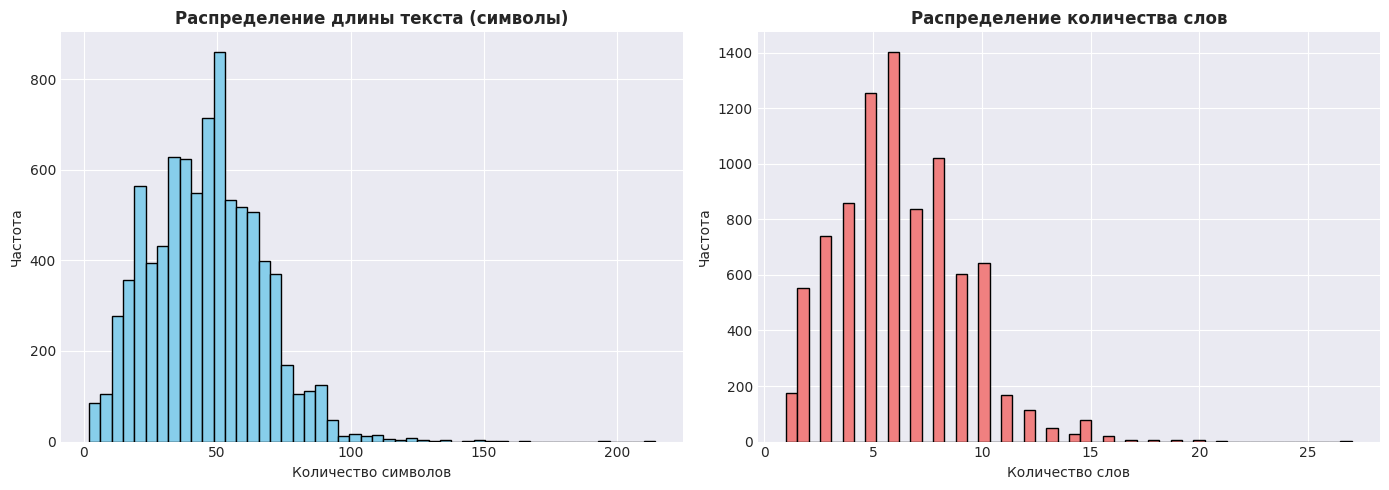


✓ График сохранен в data/processed/text_length_distribution.png


In [38]:
# Анализируем длину текстов
print("\n" + "="*80)
print("📝 АНАЛИЗ ТЕКСТОВ (Тема)")
print("="*80)

# Длина текстов в колонке "Тема"
train_df['text_length'] = train_df['Тема'].fillna('').apply(len)
train_df['word_count'] = train_df['Тема'].fillna('').apply(lambda x: len(str(x).split()))

print(f"\n📊 СТАТИСТИКА ДЛИНЫ ТЕКСТОВ (символы):")
print(train_df['text_length'].describe())

print(f"\n📊 СТАТИСТИКА КОЛИЧЕСТВА СЛОВ:")
print(train_df['word_count'].describe())

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График распределения длины текста
axes[0].hist(train_df['text_length'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Распределение длины текста (символы)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Количество символов')
axes[0].set_ylabel('Частота')

# График распределения количества слов
axes[1].hist(train_df['word_count'], bins=50, color='lightcoral', edgecolor='black')
axes[1].set_title('Распределение количества слов', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Количество слов')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.savefig('../data/processed/text_length_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ График сохранен в data/processed/text_length_distribution.png")

## 4. Распределение категорий ##

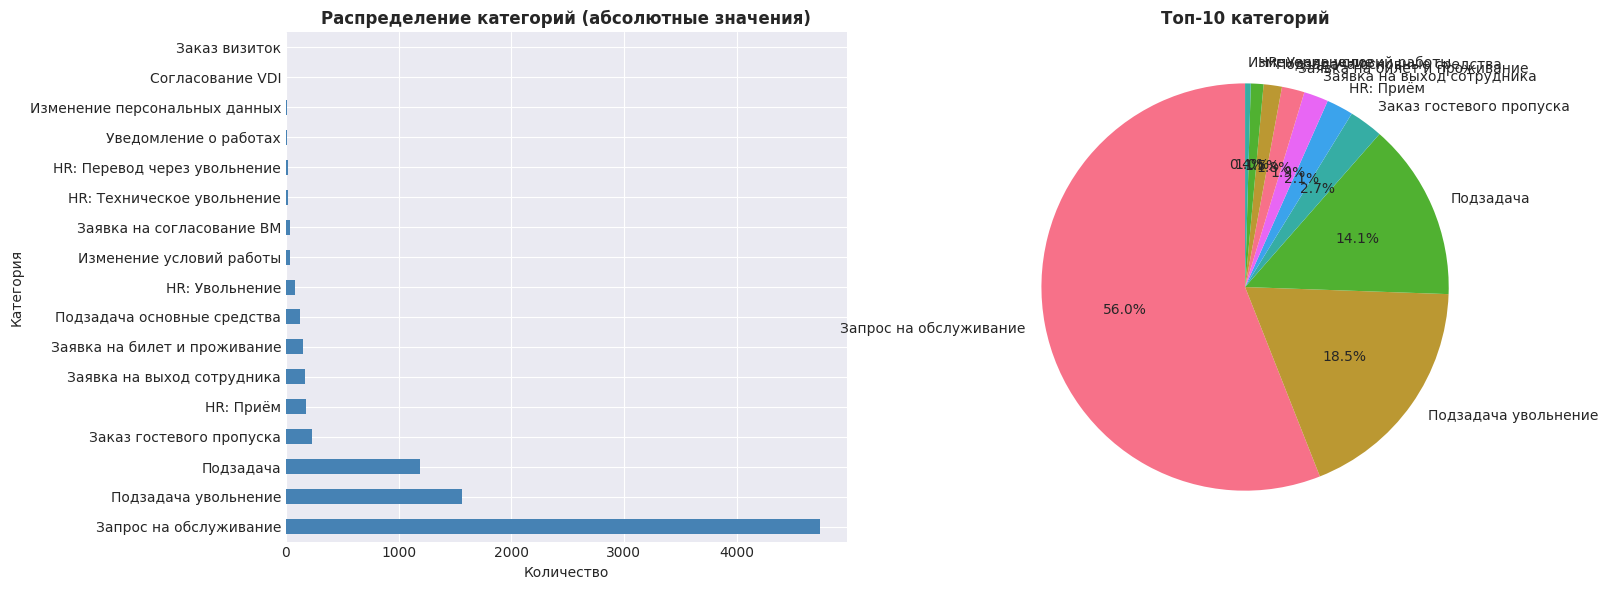

✓ График сохранен в data/processed/category_distribution.png


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
category_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Распределение категорий (абсолютные значения)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Количество')
axes[0].set_ylabel('Категория')

# Pie chart (только для топ-10)
top_10_categories = category_counts.head(10)
axes[1].pie(top_10_categories, labels=top_10_categories.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Топ-10 категорий', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/category_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ График сохранен в data/processed/category_distribution.png")

## 5. Примеры для каждой категории ##

In [43]:
print("\n" + "="*80)
print("📝 ПРИМЕРЫ ТЕКСТОВ ДЛЯ КАЖДОЙ КАТЕГОРИИ")
print("="*80)

categories = train_df['Тип задачи'].unique()

for category in categories[:5]:  # Показываем только первые 5
    print(f"\n🏷️ КАТЕГОРИЯ: '{category}'")
    print("-" * 80)
    
    # Берем 2 примера
    examples = train_df[train_df['Тип задачи'] == category]['Тема'].head(2)
    
    for i, example in enumerate(examples, 1):
        text = str(example)[:100] + "..." if len(str(example)) > 100 else str(example)
        print(f"   Пример {i}: {text}")


📝 ПРИМЕРЫ ТЕКСТОВ ДЛЯ КАЖДОЙ КАТЕГОРИИ

🏷️ КАТЕГОРИЯ: 'Запрос на обслуживание'
--------------------------------------------------------------------------------
   Пример 1: Утерян пропуск Рымарь В.С.
   Пример 2: Доступ к ресурсу БФТ

🏷️ КАТЕГОРИЯ: 'Заказ гостевого пропуска'
--------------------------------------------------------------------------------
   Пример 1: Гостевой пропуск для Ермачкова Виктория Игоревна
   Пример 2: Гостевой пропуск для Бедердинова Мария Владимировна

🏷️ КАТЕГОРИЯ: 'Подзадача'
--------------------------------------------------------------------------------
   Пример 1: ДИТ. Создание УЗ - Курочкина Лариса Викторовна
   Пример 2: Оборудование - Курочкина Лариса Викторовна 9/17/25 

🏷️ КАТЕГОРИЯ: 'HR: Приём'
--------------------------------------------------------------------------------
   Пример 1: Календарь - Курочкина Лариса Викторовна
   Пример 2: Календарь - Пестерев Максим Евгеньевич

🏷️ КАТЕГОРИЯ: 'Заявка на выход сотрудника'
-------------------------